In [16]:
print("hello world")

hello world


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
### installing packages

In [3]:
providence_metro = "providence_real_estate.csv" 
df = pd.read_csv(providence_metro)
## loading the dataset

In [4]:
print(" First 5 rows of the dataset:")
print(df.head())

print("\n Dataset shape:", df.shape)

print("\n Data types and non-null counts:")
print(df.info())

print("\n Summary statistics (numerical columns):")
print(df.describe())

 First 5 rows of the dataset:
               PROPERTY TYPE                  ADDRESS              CITY  \
0  Single Family Residential             76 Baird Ave  North Providence   
1                Condo/Co-op      420 Woodward Rd #38  North Providence   
2                Condo/Co-op       60 Hawthorne Pl #3  North Providence   
3  Single Family Residential  1375 Louisquissett Pike  North Providence   
4                Condo/Co-op  1000 Providence Pl #152        Providence   

  STATE OR PROVINCE  ZIP OR POSTAL CODE   PRICE  BEDS  BATHS  \
0                RI                2904  442500   4.0    2.0   
1                RI                2904  162500   1.0    1.0   
2                RI                2904  349900   2.0    1.5   
3                RI                2904  599000   4.0    2.5   
4                RI                2903  429900   2.0    2.0   

           LOCATION  SQUARE FEET  ...  YEAR BUILT  DAYS ON MARKET  \
0  North Providence       1966.0  ...      1950.0               4

In [5]:
# Check for missing values
print("\n Missing values per column:")
print(df.isnull().sum())


 Missing values per column:
PROPERTY TYPE           0
ADDRESS                 0
CITY                    0
STATE OR PROVINCE       0
ZIP OR POSTAL CODE      0
PRICE                   0
BEDS                   20
BATHS                  21
LOCATION                0
SQUARE FEET            20
LOT SIZE               64
YEAR BUILT             20
DAYS ON MARKET          0
$/SQUARE FEET          20
HOA/MONTH             240
LATITUDE                0
LONGITUDE               0
Walk_score              0
Bike_score              6
Transit_score          31
Unnamed: 20           321
dtype: int64


In [6]:
# Check for duplicates
print("\n Number of duplicate rows:", df.duplicated().sum())


 Number of duplicate rows: 0


In [7]:
df['PROPERTY TYPE'].value_counts()

PROPERTY TYPE
Multi-Family (2-4 Unit)      112
Single Family Residential    104
Condo/Co-op                   83
Vacant Land                   20
Townhouse                      2
Name: count, dtype: int64

In [8]:
df = df[df['PROPERTY TYPE'] != 'Vacant Land']

In [9]:
df['PROPERTY TYPE'].value_counts()

PROPERTY TYPE
Multi-Family (2-4 Unit)      112
Single Family Residential    104
Condo/Co-op                   83
Townhouse                      2
Name: count, dtype: int64

In [10]:
# Check for missing values
print("\n Missing values per column:")
print(df.isnull().sum())


 Missing values per column:
PROPERTY TYPE           0
ADDRESS                 0
CITY                    0
STATE OR PROVINCE       0
ZIP OR POSTAL CODE      0
PRICE                   0
BEDS                    0
BATHS                   1
LOCATION                0
SQUARE FEET             0
LOT SIZE               64
YEAR BUILT              0
DAYS ON MARKET          0
$/SQUARE FEET           0
HOA/MONTH             220
LATITUDE                0
LONGITUDE               0
Walk_score              0
Bike_score              6
Transit_score          29
Unnamed: 20           301
dtype: int64


In [15]:
print(" First 5 rows of the dataset:")
print(df.head())

print("\n Dataset shape:", df.shape)

print("\n Data types and non-null counts:")
print(df.info())

print("\n Summary statistics (numerical columns):")
print(df.describe())

print("\n Median:")
print(df.median(numeric_only=True))

print("\n Mode:")
print(df.mode())

 First 5 rows of the dataset:
               PROPERTY TYPE                  ADDRESS              CITY  \
0  Single Family Residential             76 Baird Ave  North Providence   
1                Condo/Co-op      420 Woodward Rd #38  North Providence   
2                Condo/Co-op       60 Hawthorne Pl #3  North Providence   
3  Single Family Residential  1375 Louisquissett Pike  North Providence   
4                Condo/Co-op  1000 Providence Pl #152        Providence   

  STATE OR PROVINCE  ZIP OR POSTAL CODE   PRICE  BEDS  BATHS  \
0                RI                2904  442500   4.0    2.0   
1                RI                2904  162500   1.0    1.0   
2                RI                2904  349900   2.0    1.5   
3                RI                2904  599000   4.0    2.5   
4                RI                2903  429900   2.0    2.0   

           LOCATION  SQUARE FEET  ...  YEAR BUILT  DAYS ON MARKET  \
0  North Providence       1966.0  ...      1950.0               4


 Correlation matrix:


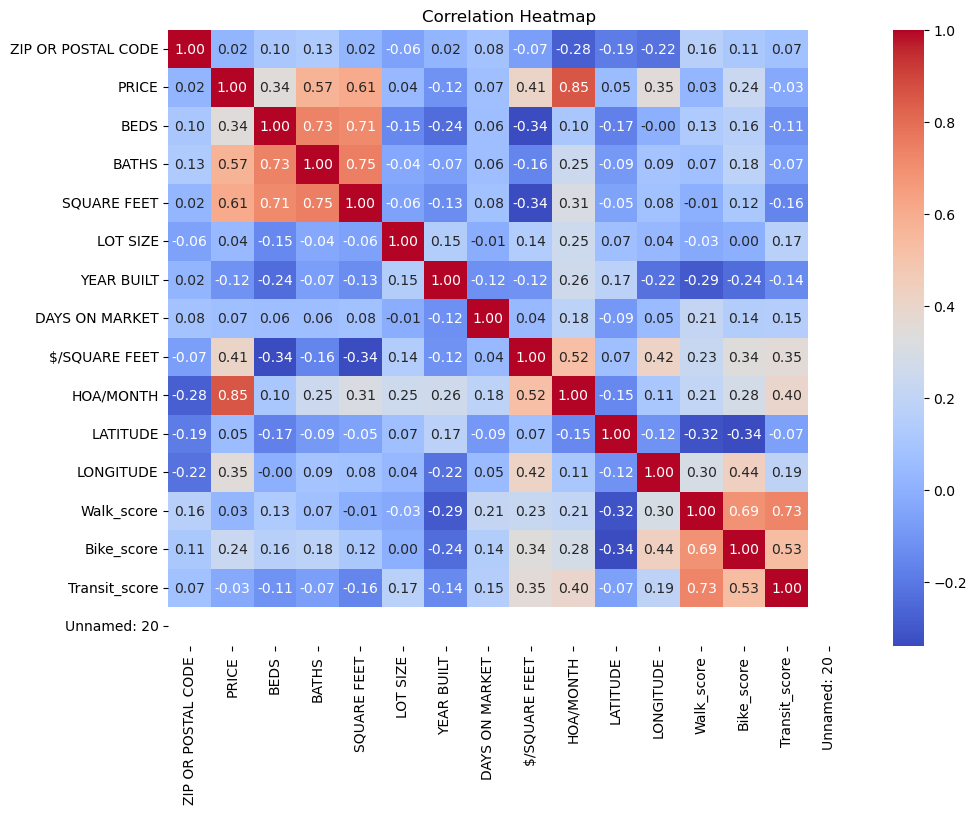

In [11]:
print("\n Correlation matrix:")
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.savefig("corr_plot.png", bbox_inches='tight')
plt.show()

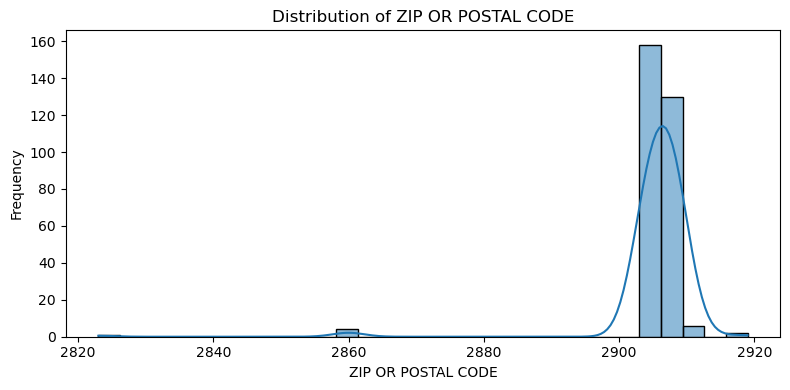

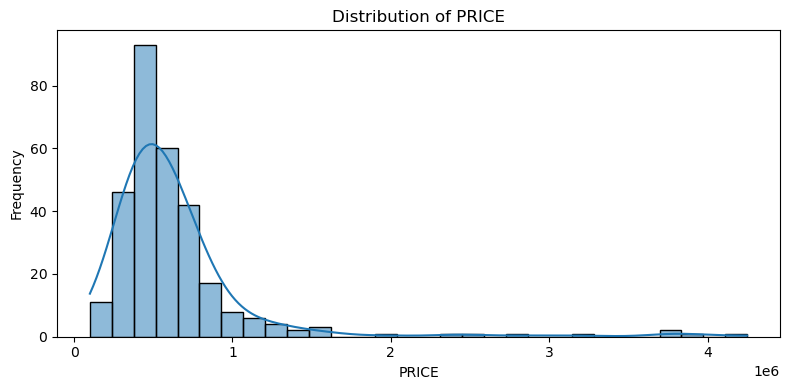

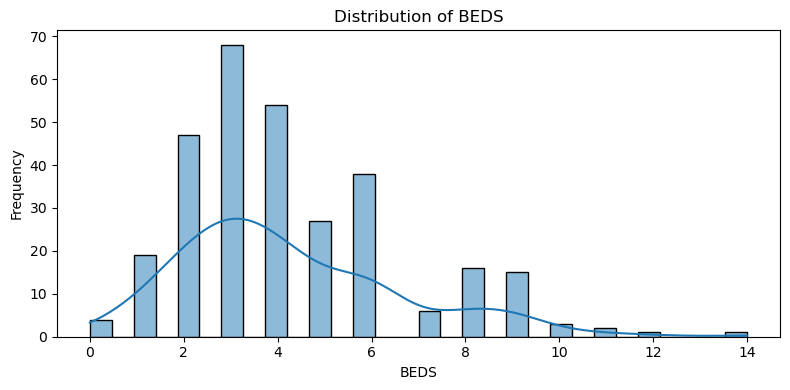

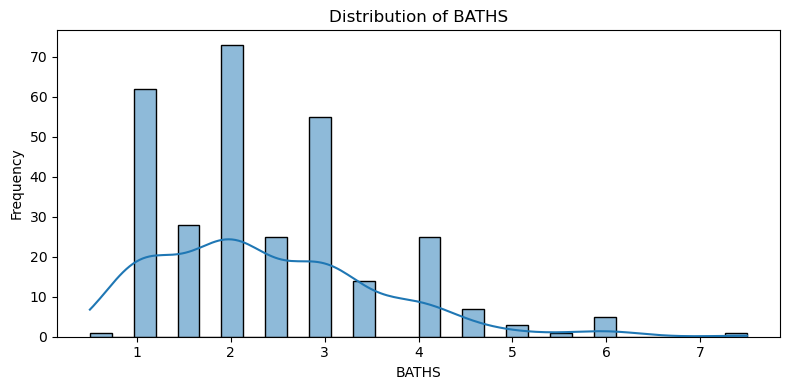

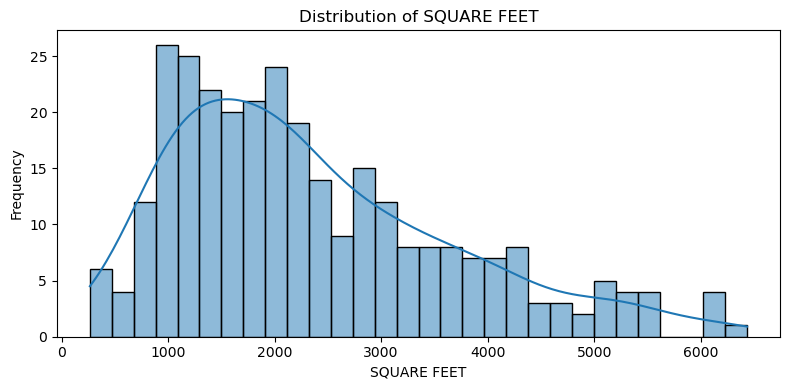

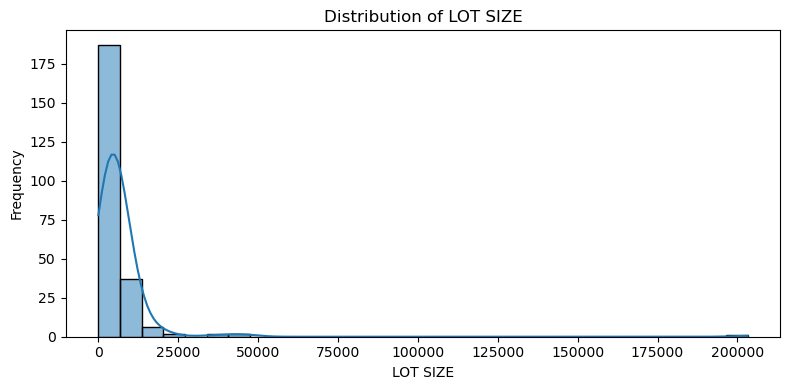

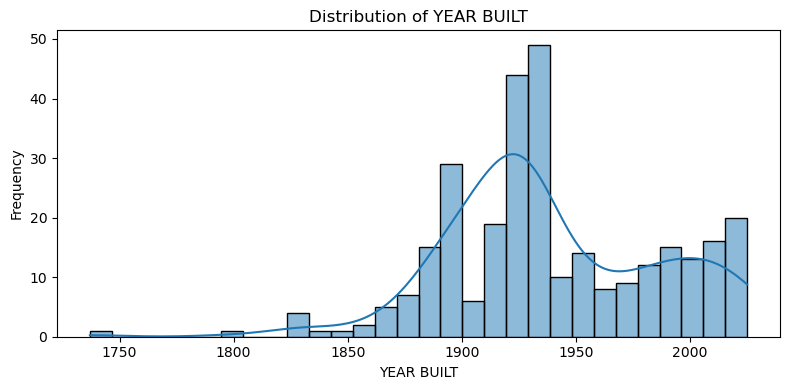

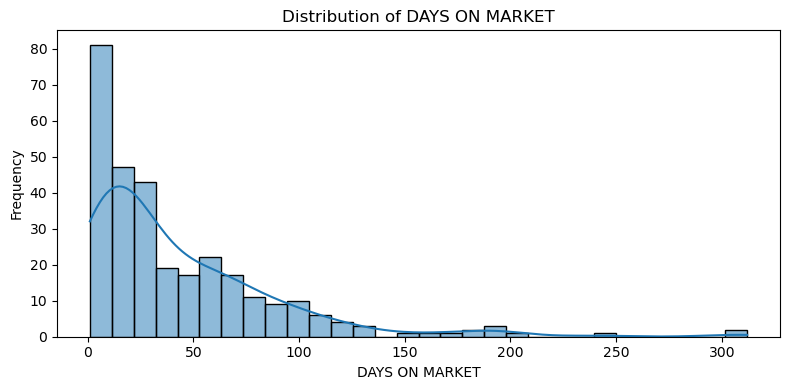

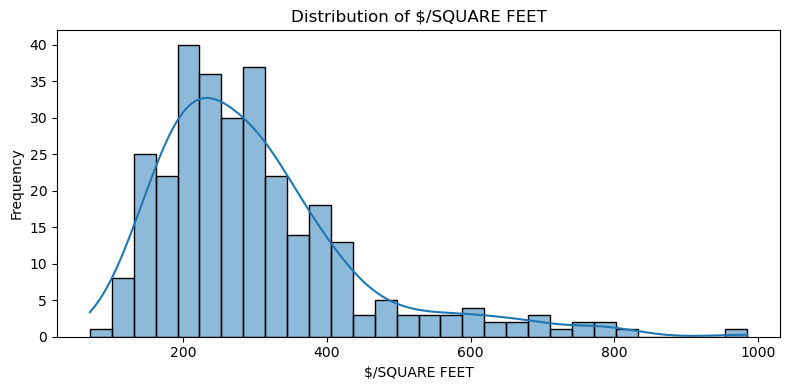

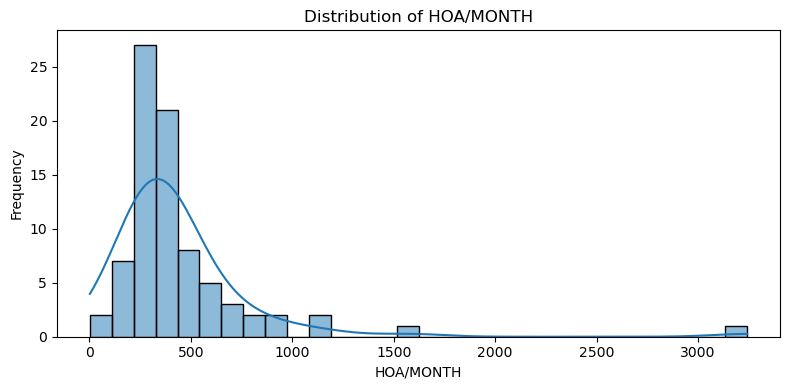

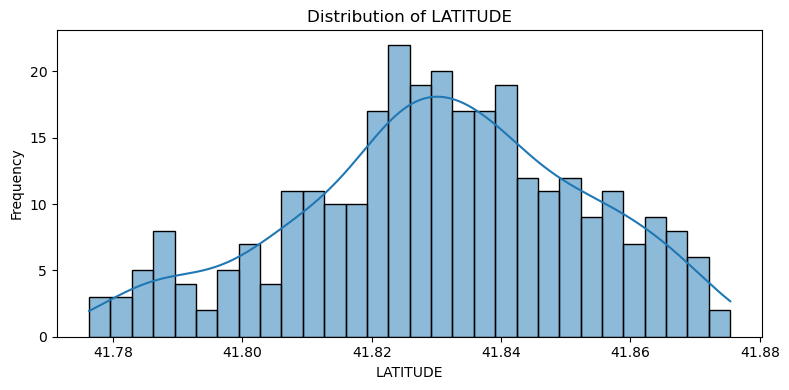

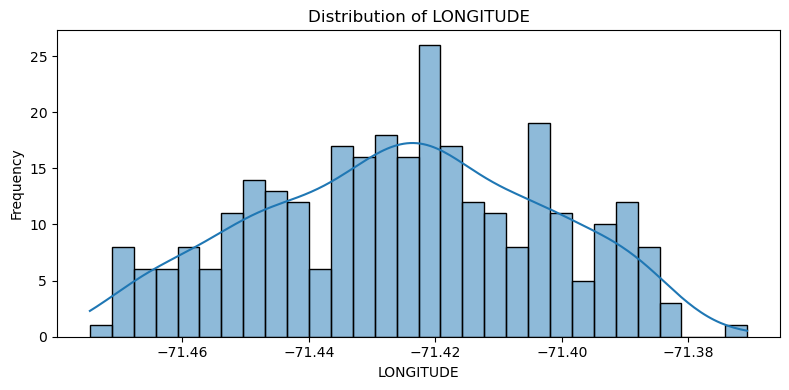

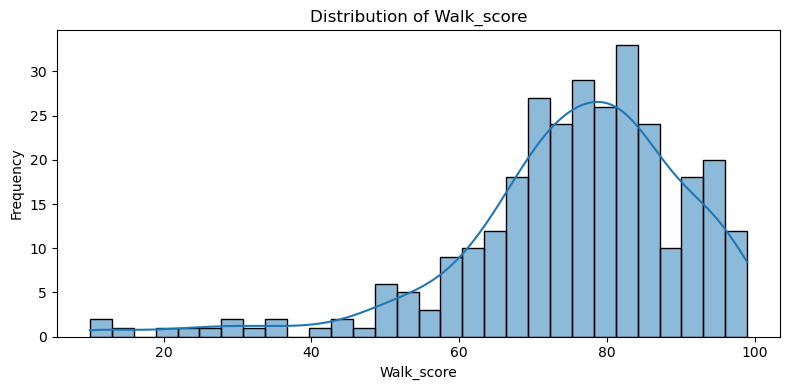

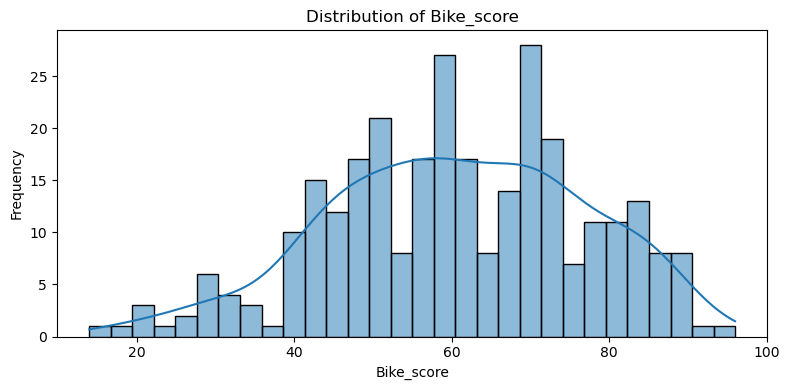

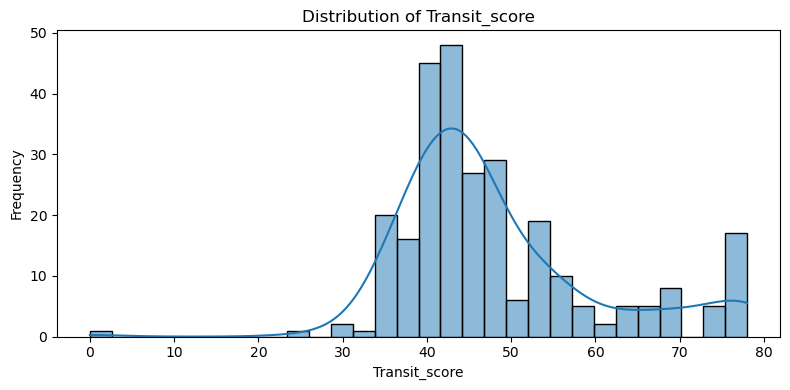

In [15]:
# Distribution of key features
numeric_columns = df.select_dtypes(include='number').columns

for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [16]:
# Replace missing HOA/MONTH values with 0
df["HOA/MONTH"] = df["HOA/MONTH"].fillna(0)

# Create a new column to indicate presence of HOA
df["Has_HOA"] = df["HOA/MONTH"].apply(lambda x: 1 if x > 0 else 0)

In [17]:
print(df[["HOA/MONTH", "Has_HOA"]].head(10))
print("✅ HOA value counts:\n", df["Has_HOA"].value_counts())

   HOA/MONTH  Has_HOA
0        0.0        0
1      301.0        1
2      260.0        1
3        0.0        0
4      592.0        1
5        0.0        0
6      230.0        1
7        0.0        0
8      400.0        1
9        0.0        0
✅ HOA value counts:
 Has_HOA
0    220
1     81
Name: count, dtype: int64


In [18]:
pip install xgboost catboost

In [19]:
## IMPORT PRIOR TO ML MODELING


import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

In [20]:
print("Column names:")
print(df.columns.tolist())

Column names:
['PROPERTY TYPE', 'ADDRESS', 'CITY', 'STATE OR PROVINCE', 'ZIP OR POSTAL CODE', 'PRICE', 'BEDS', 'BATHS', 'LOCATION', 'SQUARE FEET', 'LOT SIZE', 'YEAR BUILT', 'DAYS ON MARKET', '$/SQUARE FEET', 'HOA/MONTH', 'LATITUDE', 'LONGITUDE', 'Walk_score', 'Bike_score', 'Transit_score', 'Has_HOA']


In [21]:
y = np.log(df["PRICE"])  
X = df.drop(columns=["PRICE"])

# Define feature types
numeric_features = ['BEDS', 'BATHS', 'SQUARE FEET', 'HOA/MONTH', 'Walk_score', 'Transit_score', 'Bike_score', 'YEAR BUILT']
categorical_features = ['PROPERTY TYPE', 'CITY', 'ZIP OR POSTAL CODE', 'LOCATION']
binary_features = ['Has_HOA']

In [22]:
# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Binary features: just pass through (already 0/1)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
## train and testing split

In [24]:
# Define the models in pipelines
models = {
    "XGBoost": Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(objective='reg:squarederror', random_state=42))
    ]),
    
    "CatBoost": Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', CatBoostRegressor(verbose=0, random_state=42))
    ]),
    
    "RandomForest": Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
}

In [25]:
## cross-validation and model comparison
from sklearn.model_selection import cross_val_predict

results = []

for name, pipeline in models.items():
    print(f" Training and evaluating {name}...")
    # Cross-validation (5-fold)
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    
    mae_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    mae = -mae_scores.mean()
    
    r2_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    r2 = r2_scores.mean()
    
    results.append({
        'Model': name,
        'CV RMSE': rmse,
        'CV MAE': mae,
        'CV R²': r2
    })

# Compare all models
results_df = pd.DataFrame(results)
print("\n Cross-Validation Results:")
print(results_df.sort_values(by='CV RMSE'))

 Training and evaluating XGBoost...
 Training and evaluating CatBoost...
 Training and evaluating RandomForest...

 Cross-Validation Results:
          Model   CV RMSE    CV MAE     CV R²
1      CatBoost  0.262841  0.178460  0.705749
2  RandomForest  0.291601  0.193827  0.639399
0       XGBoost  0.291879  0.199022  0.622118


In [26]:
best_model = models['CatBoost']  ## choose best model

# Fit on training data
best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)

# Final evaluation
print("\nFinal Model Performance on Test Set:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


Final Model Performance on Test Set:
RMSE: 0.1776450769874371
MAE: 0.12843201772145998
R²: 0.8909117976970528


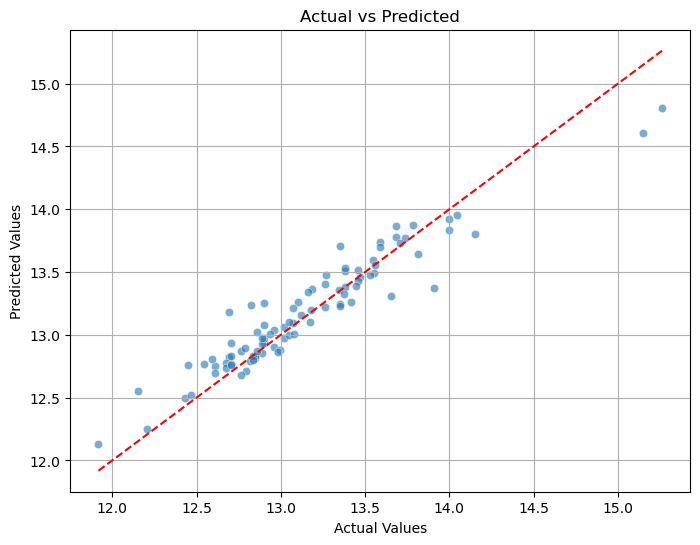

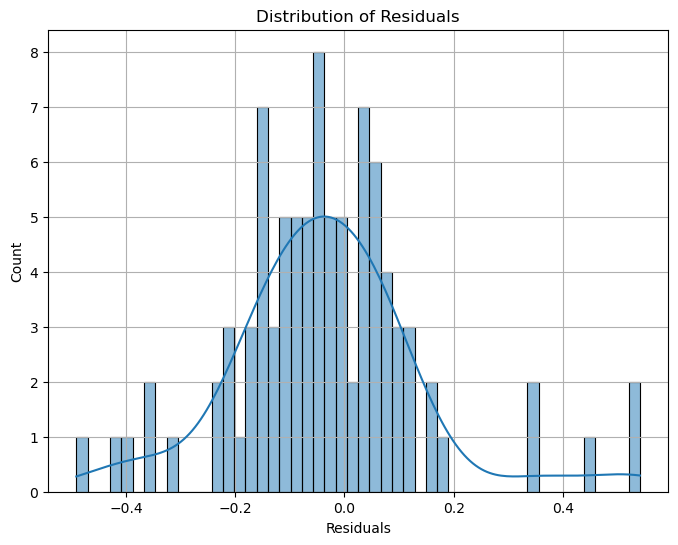

In [27]:
# Residuals
residuals = y_test - y_pred

# Plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

# Plot: Residuals distribution
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()

In [28]:
print(best_model.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['BEDS', 'BATHS', 'SQUARE FEET', 'HOA/MONTH',
                                  'Walk_score', 'Transit_score', 'Bike_score',
                                  'YEAR BUILT']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['PROPERTY TYPE', 'CITY', 'ZIP OR POSTAL CODE',
                                  'LOCATION']),
               

Number of features after preprocessing: 106
Number of importances: 106


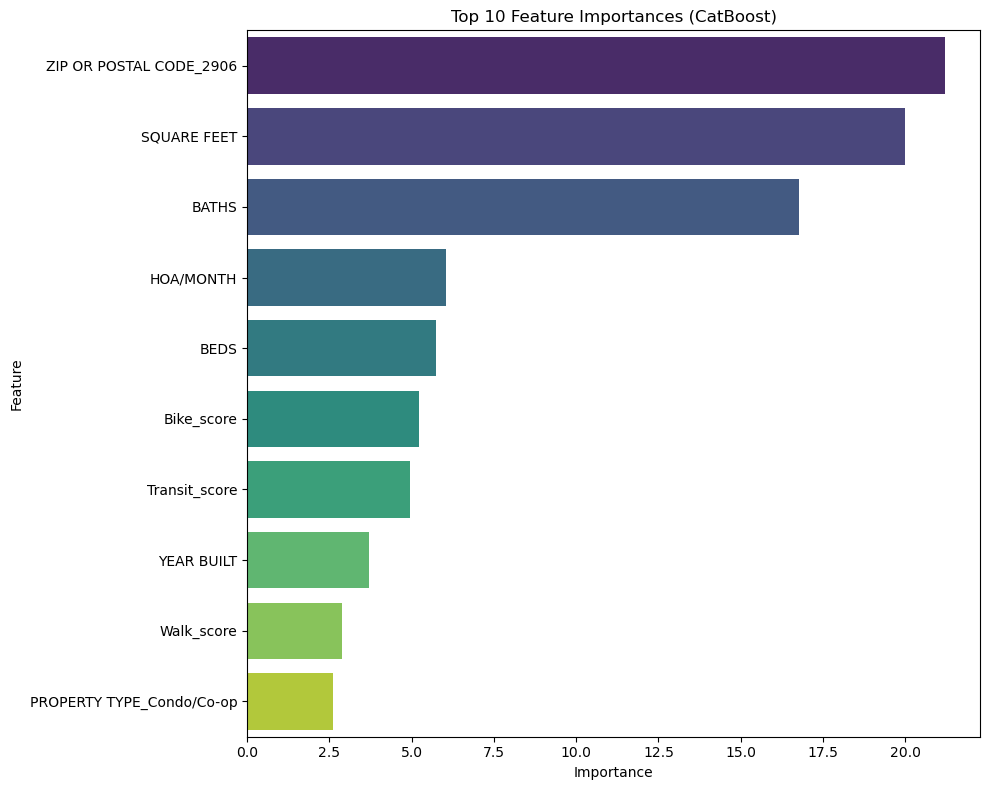

In [34]:
def get_feature_names_from_column_transformer(column_transformer):
    feature_names = []

    for name, transformer, columns in column_transformer.transformers_:
        if name == 'num':
            # Numerical features passed through a pipeline (imputer + scaler)
            feature_names.extend(columns)
        elif name == 'cat':
            # Categorical features go through one-hot encoding
            ohe = transformer.named_steps['onehot']
            categories = ohe.categories_
            for col, cats in zip(columns, categories):
                feature_names.extend([f"{col}_{cat}" for cat in cats])
        elif name == 'bin':
            # Binary features passed through without change
            feature_names.extend(columns)
    return feature_names

# Get the preprocessor from the pipeline
preprocessor = best_model.named_steps['preprocessor']

# Get the correct feature names after preprocessing
feature_names = get_feature_names_from_column_transformer(preprocessor)

# Get importances from CatBoost
catboost_model = best_model.named_steps['regressor']
importances = catboost_model.get_feature_importance()

# Sanity check: lengths must match
print(f"Number of features after preprocessing: {len(feature_names)}")
print(f"Number of importances: {len(importances)}")

# Now create the DataFrame for plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette="viridis")
plt.title("Top 10 Feature Importances (CatBoost)")
plt.tight_layout()
plt.savefig("important_features_plot.png")
plt.show()

In [30]:
import joblib
joblib.dump(best_model, "best_price_model.pkl")
## save final model

['best_price_model.pkl']

In [31]:
# save df with prediction and variables
results_df = X_test.copy()
results_df['Actual_Price'] = y_test.values
results_df['Predicted_Price'] = y_pred
results_df['Residual'] = results_df['Actual_Price'] - results_df['Predicted_Price']

In [72]:
results_df.to_csv("predicted_prices.csv", index=False)
print("Exported predictions to predicted_prices.csv")

Exported predictions to predicted_prices.csv
